In [1]:
import pandas as pd

df = pd.read_csv("data/telco.csv")

In [17]:
#Recency (Tenure)
df['Recency'] = df['Tenure Months']

In [7]:
#Frequency (Services Used)
services = [
    'Phone Service', 'Internet Service', 'Online Security',
    'Online Backup', 'Device Protection', 'Tech Support',
    'Streaming TV', 'Streaming Movies'
]

for col in services:
    df[col] = df[col].apply(lambda x: 1 if x in ['Yes', 'DSL', 'Fiber optic'] else 0)

df['Frequency'] = df[services].sum(axis=1)

In [8]:
#Monetary (Total Charges)
df['Monetary'] = df['Total Charges']

In [12]:
#Create RFM Scores
df['R_score'] = pd.qcut(df['Recency'], 4, labels=[1,2,3,4])
df['F_score'] = pd.qcut(df['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
df['M_score'] = pd.qcut(df['Monetary'].rank(method='first'), 4, labels=[1,2,3,4])

In [15]:
#Combine Scores
df['RFM_Score'] = df['R_score'].astype(str) + df['F_score'].astype(str) + df['M_score'].astype(str)

In [19]:
#Segment Customers
def segment(row):
    if row['R_score'] == 4 and row['M_score'] == 4:
        return 'High Value'
    elif row['R_score'] <= 2 and row['M_score'] >= 3:
        return 'At Risk'
    else:
        return 'Regular'

df['Segment'] = df.apply(segment, axis=1)

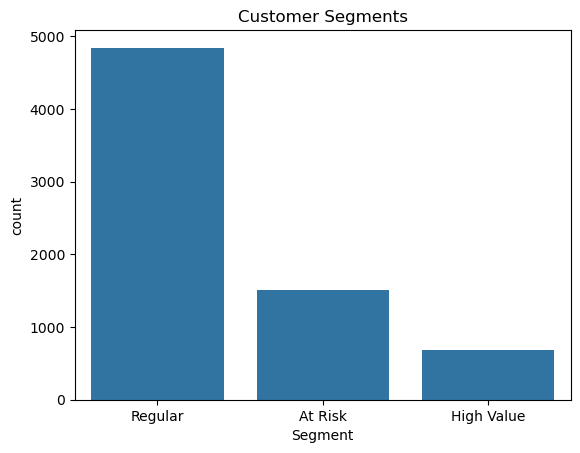

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', data=df)
plt.title("Customer Segments")
plt.show()